In [6]:
import os

# Change the current working directory to the path within Google Drive
os.chdir('/content/drive/MyDrive/Level_6_AI_')

# Verify the new current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/Level_6_AI_


In [7]:
import pandas as pd

data = pd.read_csv("./assets/mnist_test.csv",nrows=5000)


      label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0         7    0    0    0    0    0    0    0    0    0  ...      0      0   
1         2    0    0    0    0    0    0    0    0    0  ...      0      0   
2         1    0    0    0    0    0    0    0    0    0  ...      0      0   
3         0    0    0    0    0    0    0    0    0    0  ...      0      0   
4         4    0    0    0    0    0    0    0    0    0  ...      0      0   
...     ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
4995      2    0    0    0    0    0    0    0    0    0  ...      0      0   
4996      3    0    0    0    0    0    0    0    0    0  ...      0      0   
4997      2    0    0    0    0    0    0    0    0    0  ...      0      0   
4998      4    0    0    0    0    0    0    0    0    0  ...      0      0   
4999      0    0    0    0    0    0    0    0    0    0  ...      0      0   

      28x21  28x22  28x23  28x24  28x25  28x26  28x

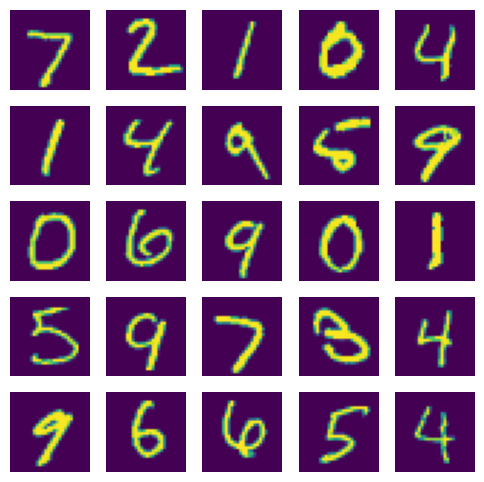

In [8]:
import matplotlib.pyplot as plt

print(data)

X = data.iloc[:,1:].values
Y = data.iloc[:,0].values

plt.figure(figsize=(6,6))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X[i].reshape(28,28))
    plt.axis("off")

plt.show()

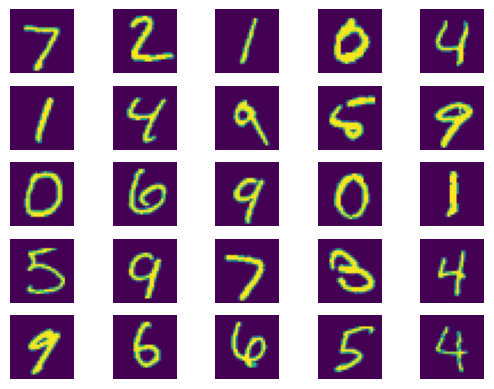

In [9]:
# Scale The Data

X = X / 255.0

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X[i].reshape(28,28))
    plt.axis("off")

plt.show()

In [10]:
print(X.shape)
print(Y.shape)

n_samples, n_features =  X.shape
n_classes = 10

(5000, 784)
(5000,)


In [11]:
# Initialize initial random ewights and bias

import numpy as np

W = np.random.rand(n_features,n_classes) * 0.01
b = np.zeros((1,n_classes))

In [12]:
# Compute scores

# So we want to z = X * weight + bias

z = X @ W + b
z.shape



(5000, 10)

In [13]:
# Convert Scores To Probability
# Softmax(z_i) = e^z_i / sum e^z

# Softmax converts scores -> probability; as such sum probability = 1.
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [14]:
# Our labels currently are like y = [7,2,1,0,4 ...]
# But softmax wants [0,0,0,0,0,1,0...]
# digit = 7 becomes [0 0 0 0 0 0 0 1 0 0]

y_onehot = np.zeros((n_samples,n_classes))
for i in range(n_samples):
    y_onehot[i, Y[i]] = 1


In [15]:
# So now we need a way to calculate loss

# We have:
# X -> input pixels
# W,b -> model parametrs
# z = X @ W + b
# probs = softmax probabilities
# y_onehot = one hot labels

# Say the true label iss 3, our model predicted
# probs [ x,x,x,x,x,x,x ....]
# We only care about the probability of 3, we can just y_onehot * probs


# Now we have the true value vs predicted value


# --- Loss func

'''

We want a loss function to be
- small when prediction is correct
- large when it's wrong
- penalize wrong predictions strongly


Using log as our loss function,
-log(p) , if p:

0.9 -> -log(p) = 0.105
0.5 -> -log(p) = 0.69
0.01 -> -log(p) = 4.60

so high probability = tiny loss
low probability = huge loss, which is a good loss function

Could we use some other loss function? sure. MSE works, Hinge Loss works, absolute error works too but cross entropy loss makes more "sense".
'''

def calculate_loss(probs, y_onehot):
    log_probs = np.log(probs + 1e-9) # 1e-9 prevents log(0)
    loss_per_sample = -np.sum(y_onehot * log_probs, axis=1)
    return np.mean(loss_per_sample)



Epoch 0, Loss: 2.3005
Epoch 100, Loss: 0.6298
Epoch 200, Loss: 0.5023
Epoch 300, Loss: 0.4465
Epoch 400, Loss: 0.4125
Epoch 500, Loss: 0.3886
Epoch 600, Loss: 0.3704
Epoch 700, Loss: 0.3558
Epoch 800, Loss: 0.3437
Epoch 900, Loss: 0.3334


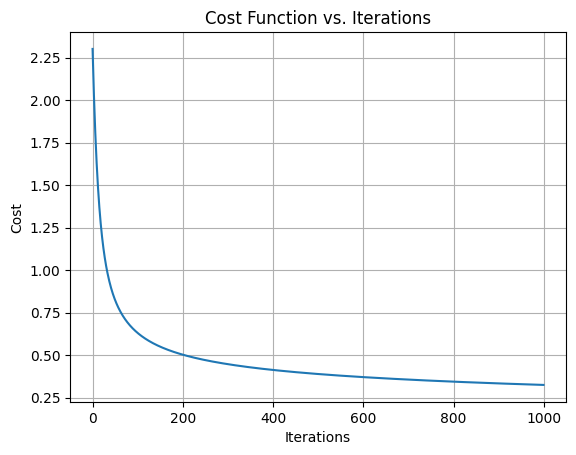

In [16]:
# Now the actual learning part

lr = 0.1
cost_history = []

for epoch in range(1000):
    z = X @ W + b
    probs = softmax(z)
    loss = calculate_loss(probs, y_onehot)
    cost_history.append(loss)

    dz = probs - y_onehot
    dW = X.T @ dz / n_samples
    db = np.sum(dz, axis=0, keepdims=True) / n_samples

    W = W - lr * dW
    b = b - lr * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Cost plot
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [17]:
# Now that the trainings done

z = X @ W + b
probs = softmax(z)

# Pick the class with highest probability

preds = np.argmax(probs,axis=1) # for each row, gives index of the highest probability column

accuracy = np.mean(preds == Y)
print("accuracy: ", accuracy)


accuracy:  0.9122


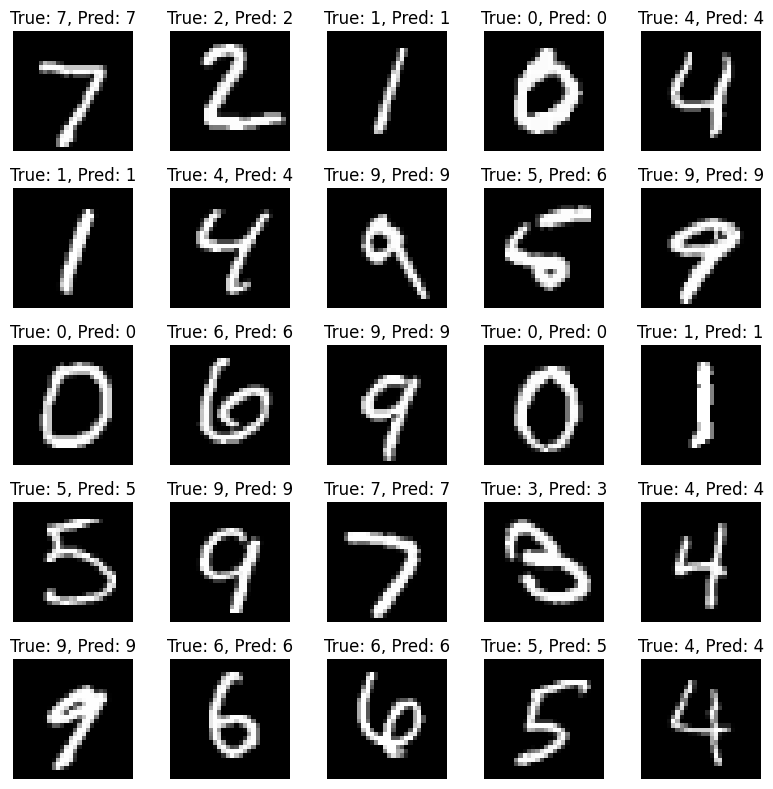

In [18]:
plt.figure(figsize = (8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap="gray")
    plt.title(f"True: {Y[i]}, Pred: {preds[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


Precision: 0.91
Recall:    0.91
F1-Score:  0.91


array([[447,   0,   0,   1,   1,   2,   6,   0,   3,   0],
       [  0, 557,   1,   3,   1,   2,   2,   0,   5,   0],
       [  3,   1, 472,   8,   6,   1,   8,  14,  14,   3],
       [  0,   1,  10, 447,   1,  15,   3,  11,   7,   5],
       [  0,   1,   1,   0, 461,   0,   7,   0,   4,  26],
       [  9,   4,   1,  16,   6, 395,   5,   4,  14,   2],
       [  8,   3,   2,   2,   3,   8, 433,   1,   2,   0],
       [  3,   9,  10,   2,   8,   1,   1, 457,   4,  17],
       [  3,   4,   5,  11,   4,  14,   4,   6, 434,   4],
       [  5,   6,   1,   7,  20,   3,   1,  11,   8, 458]])

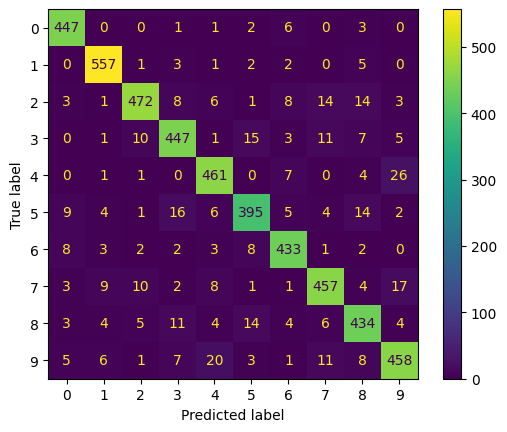

In [19]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score,f1_score, ConfusionMatrixDisplay

cm = confusion_matrix(Y, preds)
precision = precision_score(Y, preds, average='weighted')
recall = recall_score(Y, preds, average='weighted')
f1 = f1_score(Y, preds, average='weighted')

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

display(cm)


ConfusionMatrixDisplay.from_predictions(Y, preds)

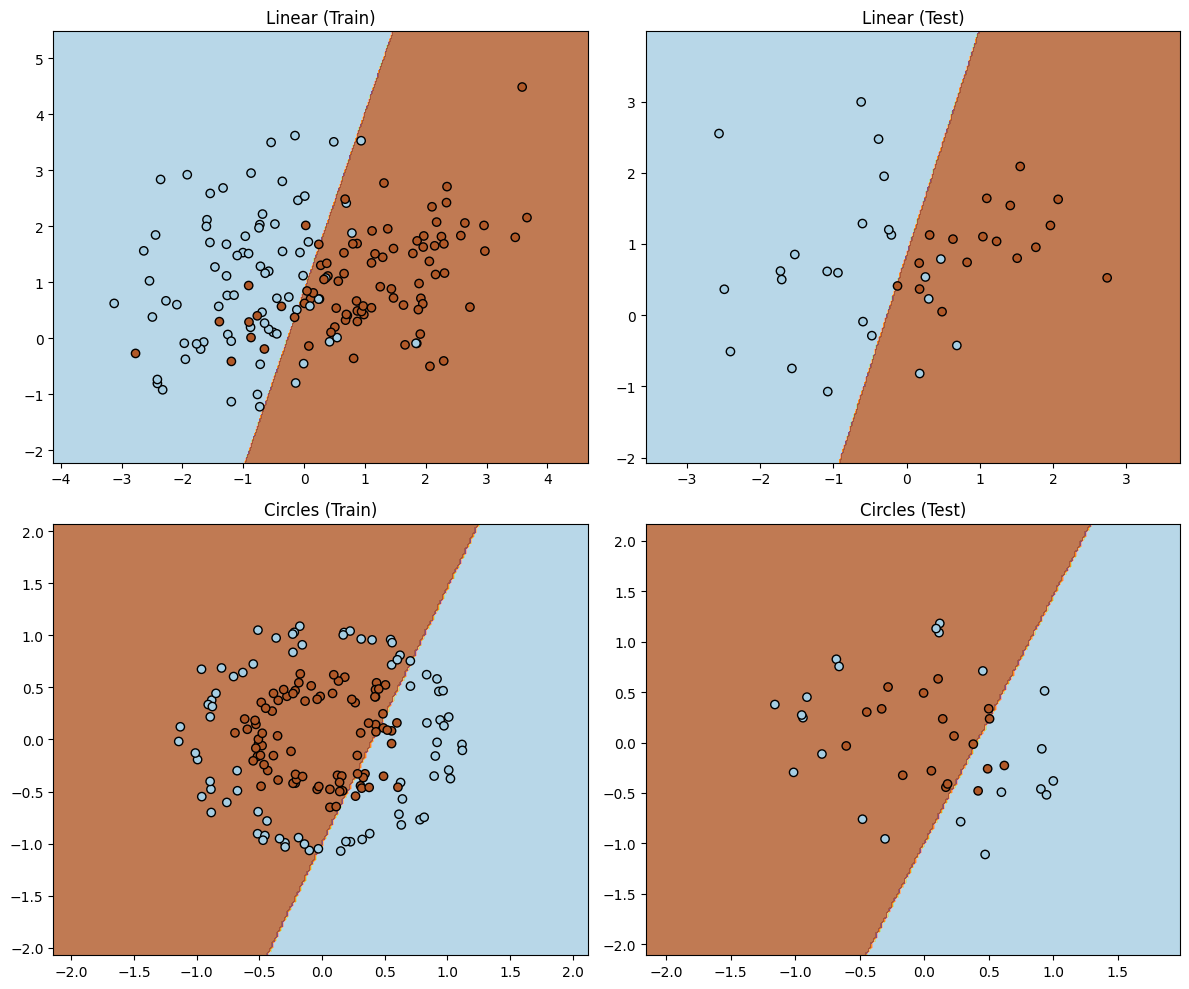

In [22]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X1, y1 = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

m1 = LogisticRegression()

m1.fit(X1_train, y1_train)

X2, y2 = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

m2 = LogisticRegression()

m2.fit(X2_train, y2_train)

def plot_boundary(ax, model, X, y, title):
    h = 0.02
    xx, yy = np.meshgrid(np.arange(X[:,0].min()-1, X[:,0].max()+1, h), np.arange(X[:,1].min()-1, X[:,1].max()+1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_boundary(axes[0,0], m1, X1_train, y1_train, 'Linear (Train)')
plot_boundary(axes[0,1], m1, X1_test,  y1_test,  'Linear (Test)')
plot_boundary(axes[1,0], m2, X2_train, y2_train, 'Circles (Train)')
plot_boundary(axes[1,1], m2, X2_test,  y2_test,  'Circles (Test)')
plt.tight_layout()
plt.show()